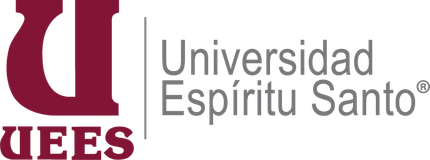

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 3 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E3.1 · K-means y validación de clusters</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Programar K-means, elegir k con criterios internos, medir la estabilidad de una segmentación y analizar su composición por subgrupos antes de usarla con personas. |
| **Resultado de aprendizaje** | RDA2 · competencias CG-G2 y CE-G2 (según el sílabo) |
| **Duración** | ≈ 4.5 h (el nivel 3 es el laboratorio guiado del sábado) |
| **Teoría** | Manual M3 §1–3, §5 y §9 · Animaciones A3.1, A3.2 y A3.4 · Videos V3.1 y V3.4 |
| **Datos** | Sintéticos (`make_blobs`) · **Bank Marketing** (OpenML 1461: 45 211 clientes de un banco portugués; usamos sus variables **sin** la etiqueta) |

**Niveles:** 1 · Lloyd y k-means++ desde cero → 2 · `KMeans`, silhouette, Davies-Bouldin y estabilidad → 3 · segmentación de clientes y perfiles → 4 · reto ético: ¿la segmentación discrimina?

## 0 · Configuración

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
COLORES = list(UEES.values()) + ["#5FB3CE", "#E07A9B", "#1C1A1B"]
print(f"scikit-learn {sklearn.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · semilla 2026


## Nivel 1 · Desde cero (prelaboratorio)

K-means busca $k$ centroides que minimicen la **inercia**, la suma de distancias al cuadrado de cada punto a su centroide:

$$J = \sum_{j=1}^{k}\sum_{x \in C_j}\lVert x - \mu_j\rVert^2$$

El algoritmo de **Lloyd** alterna dos pasos hasta que nada cambia: (1) **asignar** cada punto al centroide más cercano; (2) **actualizar** cada centroide como la media de sus puntos. Cada paso baja (o mantiene) $J$, así que converge, pero a un **óptimo local** que depende del inicio.

In [2]:
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=600, centers=[[-4, -2], [0, 3], [4, -1], [1, -4.5], [-3.5, 3.5]], cluster_std=[1.0, 0.9, 1.1, 0.7, 0.8], random_state=SEED)


def lloyd(X, centroides, max_iter=100):
    """Devuelve (etiquetas, centroides, historial de inercia)."""
    C = np.array(centroides, dtype=float)
    hist = []
    for _ in range(max_iter):
        # TODO: distancias al cuadrado de cada punto a cada centroide, asignación, inercia y actualización.
        d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
        etiquetas = d2.argmin(axis=1)
        hist.append(float(d2[np.arange(len(X)), etiquetas].sum()))
        nuevos = np.array([X[etiquetas == j].mean(axis=0) if np.any(etiquetas == j) else C[j] for j in range(len(C))])
        if np.allclose(nuevos, C):
            break
        C = nuevos
    return etiquetas, C, hist


def kmeans_pp(X, k, rng):
    """Inicialización k-means++: cada nuevo centro se elige con probabilidad proporcional a D(x)²."""
    centros = [X[rng.integers(len(X))]]
    for _ in range(1, k):
        # TODO: D(x)² = distancia al cuadrado al centro más cercano ya elegido; elige el siguiente con probabilidad ∝ D².
        d2 = np.min(((X[:, None, :] - np.array(centros)[None, :, :]) ** 2).sum(axis=2), axis=1)
        centros.append(X[rng.choice(len(X), p=d2 / d2.sum())])
    return np.array(centros)


rng = np.random.default_rng(SEED)
finales = {"aleatoria": [], "k-means++": []}
for rep in range(30):
    ini_azar = Xb[rng.choice(len(Xb), 5, replace=False)]
    finales["aleatoria"].append(lloyd(Xb, ini_azar)[2][-1])
    finales["k-means++"].append(lloyd(Xb, kmeans_pp(Xb, 5, rng))[2][-1])
resumen_ini = pd.DataFrame({k: {"inercia mínima": min(v), "inercia mediana": np.median(v), "peor inercia": max(v),
                                "% de corridas en el mejor óptimo": np.mean(np.isclose(v, min(min(finales['aleatoria']), min(finales['k-means++'])), rtol=1e-3)) * 100}
                            for k, v in finales.items()}).T.round(1)
resumen_ini

,inercia mínima,inercia mediana,peor inercia,% de corridas en el mejor óptimo
aleatoria,1035.6,1035.6,2295.7,63.3
k-means++,1035.6,1035.6,1759.2,90.0


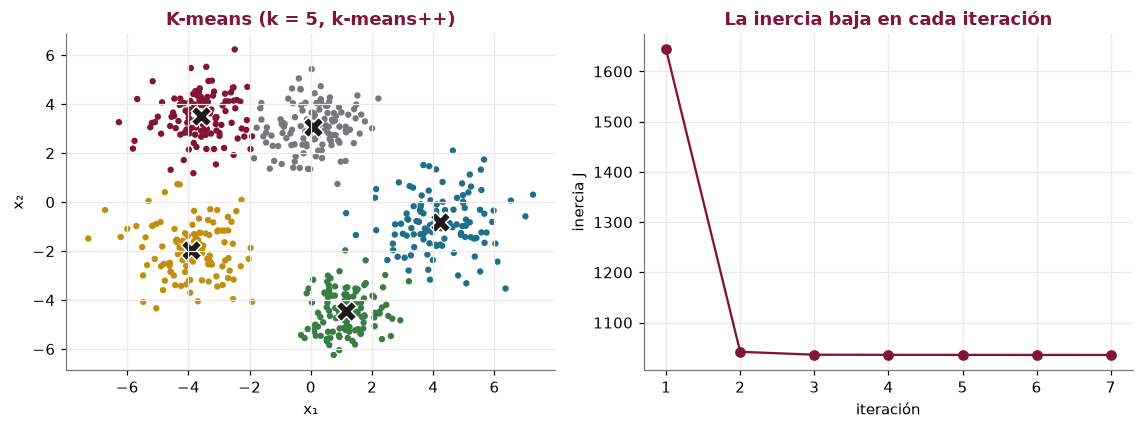

In [3]:
etq, cent, hist = lloyd(Xb, kmeans_pp(Xb, 5, np.random.default_rng(SEED)))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].scatter(Xb[:, 0], Xb[:, 1], c=[COLORES[e] for e in etq], s=10)
axes[0].scatter(cent[:, 0], cent[:, 1], marker="X", s=180, c="#1C1A1B", edgecolors="white")
axes[0].set(title="K-means (k = 5, k-means++)", xlabel="x₁", ylabel="x₂")
axes[1].plot(range(1, len(hist) + 1), hist, "o-", color=UEES["vino"])
axes[1].set(title="La inercia baja en cada iteración", xlabel="iteración", ylabel="inercia J")
plt.tight_layout()
plt.show()

**Qué observar.** Con inicio aleatorio, varias corridas quedan atrapadas en óptimos locales (dos centroides compartiendo un grupo y un grupo partido en dos); k-means++ reparte mejor los centros iniciales y casi siempre llega al mejor óptimo. Por eso scikit-learn usa k-means++ y varias inicializaciones (`n_init`).

## Nivel 2 · Con scikit-learn

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score

ini = kmeans_pp(Xb, 5, np.random.default_rng(SEED))
km_sk = KMeans(n_clusters=5, init=ini, n_init=1, tol=0, random_state=SEED).fit(Xb)      # tol=0: hasta que nada cambie, como tu Lloyd
etq_prop, cent_prop, hist_prop = lloyd(Xb, ini)
print(f"inercia · scikit-learn {km_sk.inertia_:.3f} · tuya {hist_prop[-1]:.3f}")
assert np.isclose(km_sk.inertia_, hist_prop[-1], rtol=1e-5), "Tu Lloyd no llega a la misma solución que KMeans con el mismo inicio."
assert adjusted_rand_score(km_sk.labels_, etq_prop) == 1.0
print("✓ Tu K-means coincide con scikit-learn")

inercia · scikit-learn 1035.598 · tuya 1035.598
✓ Tu K-means coincide con scikit-learn


### 2.1 Elegir k sin etiquetas
- **Codo:** la inercia siempre baja al subir k; se busca dónde deja de bajar mucho.
- **Silhouette** $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$: $a(i)$ es la distancia media a su propio cluster y $b(i)$ al cluster vecino más cercano. Va de −1 a 1; más alto es mejor.
- **Davies-Bouldin:** compara la dispersión de cada cluster con la separación al más parecido; **más bajo** es mejor.

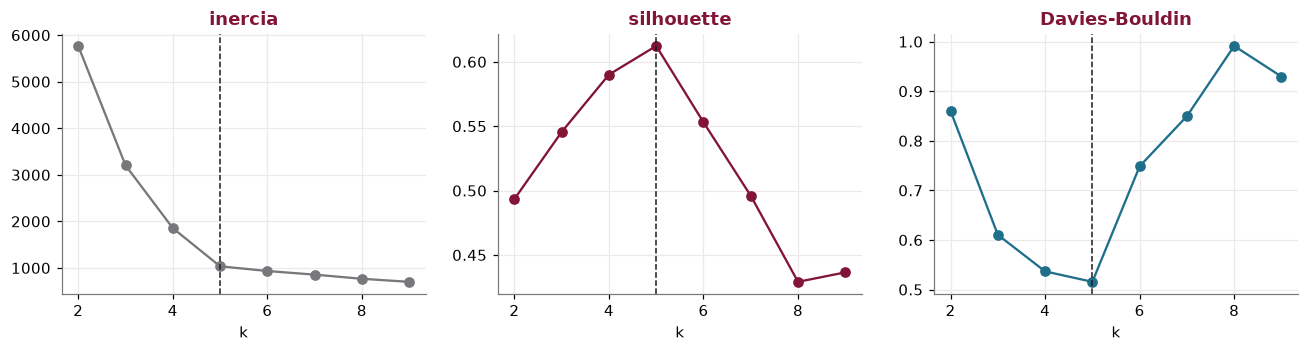

,inercia,silhouette,Davies-Bouldin
k,,,
2,5766.902,0.493,0.860
3,3204.155,0.546,0.610
4,1855.759,0.590,0.537
5,1035.598,0.612,0.516
6,934.557,0.553,0.749
7,856.404,0.496,0.850
8,767.550,0.429,0.991
9,701.691,0.437,0.929


In [5]:
filas = []
for k in range(2, 10):
    m = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xb)
    filas.append({"k": k, "inercia": m.inertia_, "silhouette": silhouette_score(Xb, m.labels_), "Davies-Bouldin": davies_bouldin_score(Xb, m.labels_)})
tabla_k = pd.DataFrame(filas).set_index("k")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, col, color in zip(axes, tabla_k.columns, (UEES["gris"], UEES["vino"], UEES["azul"])):
    ax.plot(tabla_k.index, tabla_k[col], "o-", color=color)
    ax.axvline(5, ls="--", color="#1C1A1B", lw=1)
    ax.set(title=col, xlabel="k")
plt.tight_layout()
plt.show()
tabla_k.round(3)

### 2.2 Estabilidad
Una segmentación útil no debería cambiar mucho si repetimos el algoritmo con otra semilla o con otra muestra. Medimos el **índice de Rand ajustado (ARI)** entre soluciones: 1 = idénticas, 0 = coincidencia al azar.

In [6]:
def estabilidad(X, k, repeticiones=10, semilla=SEED):
    """ARI medio entre las etiquetas de K-means entrenado en muestras bootstrap y evaluado sobre todos los puntos."""
    r = np.random.default_rng(semilla)
    etiquetas = []
    for _ in range(repeticiones):
        idx = r.integers(0, len(X), len(X))
        etiquetas.append(KMeans(n_clusters=k, n_init=5, random_state=int(r.integers(1e6))).fit(X[idx]).predict(X))
    aris = [adjusted_rand_score(etiquetas[i], etiquetas[j]) for i in range(repeticiones) for j in range(i + 1, repeticiones)]
    return float(np.mean(aris))


estab_blobs = {k: estabilidad(Xb, k) for k in (3, 4, 5, 6, 8)}
print("ARI medio entre bootstraps:", {k: round(v, 3) for k, v in estab_blobs.items()})

ARI medio entre bootstraps: {3: 0.998, 4: 0.993, 5: 0.988, 6: 0.898, 8: 0.769}


**Qué observar.** Con el k verdadero (5) la silhouette es máxima, Davies-Bouldin es mínimo y la solución es **estable** (ARI cercano a 1). Con k equivocado el algoritmo parte grupos de maneras distintas en cada muestra y el ARI baja.

## Nivel 3 · Laboratorio: segmentar clientes de un banco

Usamos las variables de **comportamiento** de Bank Marketing (saldo, contactos de la campaña actual y anteriores, días desde el último contacto) y dejamos fuera la respuesta a la campaña. Excluimos a propósito **edad, estado civil, trabajo y educación**: los usaremos en el nivel 4 para auditar la segmentación.

In [7]:
from sklearn.datasets import fetch_openml
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer, StandardScaler

banco = fetch_openml(data_id=1461, as_frame=True)
nombres = ["age", "job", "marital", "education", "default", "balance", "housing", "loan", "contact", "day", "month",
           "duration", "campaign", "pdays", "previous", "poutcome"]
B = banco.data.set_axis(nombres, axis=1)
B["y"] = (banco.target == "2").astype(int)
B["contactado_antes"] = (B["pdays"] != -1).astype(int)          # pdays = −1 significa "nunca contactado"
B["tiene_vivienda"] = (B["housing"] == "yes").astype(int)
B["tiene_prestamo"] = (B["loan"] == "yes").astype(int)
comportamiento = ["balance", "campaign", "previous", "contactado_antes", "tiene_vivienda", "tiene_prestamo"]
Xc = B[comportamiento].to_numpy(float)
print(f"{len(B)} clientes · variables de comportamiento: {comportamiento}")
B[comportamiento].describe().round(2)

45211 clientes · variables de comportamiento: ['balance', 'campaign', 'previous', 'contactado_antes', 'tiene_vivienda', 'tiene_prestamo']


,balance,campaign,previous,contactado_antes,tiene_vivienda,tiene_prestamo
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,1362.27,2.76,0.58,0.18,0.56,0.16
std,3044.77,3.10,2.30,0.39,0.50,0.37
min,-8019.00,1.00,0.00,0.00,0.00,0.00
25%,72.00,1.00,0.00,0.00,0.00,0.00
50%,448.00,2.00,0.00,0.00,1.00,0.00
75%,1428.00,3.00,0.00,0.00,1.00,0.00
max,102127.00,63.00,275.00,1.00,1.00,1.00


`balance` y `campaign` son muy asimétricas (pocos clientes con saldos o contactos enormes). Con distancias euclidianas esos valores extremos dominarían los clusters, así que usamos una transformación **por cuantiles** (rango uniforme) en lugar de la estandarización simple (animación A3.2).

In [8]:
prep = QuantileTransformer(n_quantiles=200, output_distribution="uniform", random_state=SEED)
Zc = prep.fit_transform(Xc)
filas = []
for k in range(2, 9):
    m = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Zc)
    filas.append({"k": k, "inercia": m.inertia_, "silhouette (muestra de 8000)": silhouette_score(Zc, m.labels_, sample_size=8000, random_state=SEED),
                  "Davies-Bouldin": davies_bouldin_score(Zc, m.labels_)})
tabla_banco = pd.DataFrame(filas).set_index("k").round(3)
tabla_banco

,inercia,silhouette (muestra de 8000),Davies-Bouldin
k,,,
2,26735.807,0.417,1.084
3,17532.443,0.421,1.036
4,13877.290,0.453,0.959
5,11906.620,0.468,0.998
6,10064.070,0.445,0.933
7,8499.854,0.450,0.888
8,7001.277,0.486,0.876


In [9]:
K_BANCO = 4
estab_banco = {k: estabilidad(Zc, k, repeticiones=6) for k in (3, 4, 5, 6)}
print("Estabilidad (ARI entre bootstraps):", {k: round(v, 3) for k, v in estab_banco.items()})
km_banco = KMeans(n_clusters=K_BANCO, n_init=10, random_state=SEED).fit(Zc)
B["segmento"] = km_banco.labels_
perfil = B.groupby("segmento").agg(clientes=("y", "size"), saldo_mediano=("balance", "median"), contactos_campaña=("campaign", "mean"),
                                   contactado_antes=("contactado_antes", "mean"), vivienda=("tiene_vivienda", "mean"),
                                   prestamo=("tiene_prestamo", "mean"), tasa_de_contratacion=("y", "mean")).round(3)
perfil["% de clientes"] = (perfil["clientes"] / len(B) * 100).round(1)
perfil

Estabilidad (ARI entre bootstraps): {3: 1.0, 4: 0.884, 5: 0.843, 6: 0.893}


,clientes,saldo_mediano,contactos_campaña,contactado_antes,vivienda,prestamo,tasa_de_contratacion,% de clientes
segmento,,,,,,,,
0,16471,420.0,2.835,0.0,1.000,0.000,0.067,36.4
1,14362,522.0,3.001,0.0,0.000,0.000,0.134,31.8
2,8257,602.0,2.056,1.0,0.623,0.136,0.231,18.3
3,6121,238.0,2.972,0.0,0.575,1.000,0.059,13.5


**Qué observar.** Con datos reales las métricas internas **no señalan un k único**: la silhouette sigue subiendo hasta k = 8 (las variables binarias crean grupos discretos) y Davies-Bouldin mejora poco a poco. Elegimos k = 4 porque es estable (ARI ≈ 0.88 entre bootstraps) y, sobre todo, **útil**: cada segmento se describe con una frase: "con hipoteca, nunca contactados", "sin hipoteca ni préstamo, nunca contactados", "contactados en campañas anteriores" y "con préstamo personal". La última columna es una **validación externa**: la respuesta a la campaña no participó en el clustering, pero la tasa de contratación va de ≈ 6 % a ≈ 23 % entre segmentos, así que la segmentación captura algo relevante para el negocio.

## Nivel 4 · Reto ético: ¿la segmentación discrimina?

No usamos edad ni estado civil para segmentar. ¿Significa eso que los segmentos son neutrales respecto de esos grupos? Medimos la **composición** de cada segmento y la comparamos con la población.

In [10]:
B["grupo_edad"] = pd.cut(B["age"], [0, 29, 44, 59, 120], labels=["18–29", "30–44", "45–59", "60+"])


def composicion(df, grupo):
    """Porcentaje de cada grupo dentro de cada segmento y razón frente a su peso en la población."""
    tabla = pd.crosstab(df["segmento"], df[grupo], normalize="index")
    poblacion = df[grupo].value_counts(normalize=True)
    # TODO: la razón de representación es (proporción del grupo en el segmento) / (proporción del grupo en la población).
    razon = tabla / poblacion
    return (tabla * 100).round(1), razon.round(2)


comp_edad, razon_edad = composicion(B, "grupo_edad")
comp_civil, razon_civil = composicion(B, "marital")
print("Composición por edad (% dentro de cada segmento):")
display(comp_edad)
print("Razón de representación por edad (1 = igual que en la población):")
display(razon_edad)
print("Razón de representación por estado civil:")
razon_civil

Composición por edad (% dentro de cada segmento):


grupo_edad,18–29,30–44,45–59,60+
segmento,,,,
0,12.7,60.2,26.1,1.0
1,9.9,45.9,37.3,6.9
2,11.8,55.7,25.9,6.6
3,12.8,51.7,34.2,1.4


Razón de representación por edad (1 = igual que en la población):


grupo_edad,18–29,30–44,45–59,60+
segmento,,,,
0,1.09,1.12,0.85,0.26
1,0.84,0.86,1.22,1.74
2,1.01,1.04,0.84,1.66
3,1.09,0.96,1.11,0.34


Razón de representación por estado civil:


marital,divorced,married,single
segmento,,,
0,0.99,1.00,1.00
1,0.97,1.00,1.02
2,0.98,0.95,1.10
3,1.13,1.06,0.81


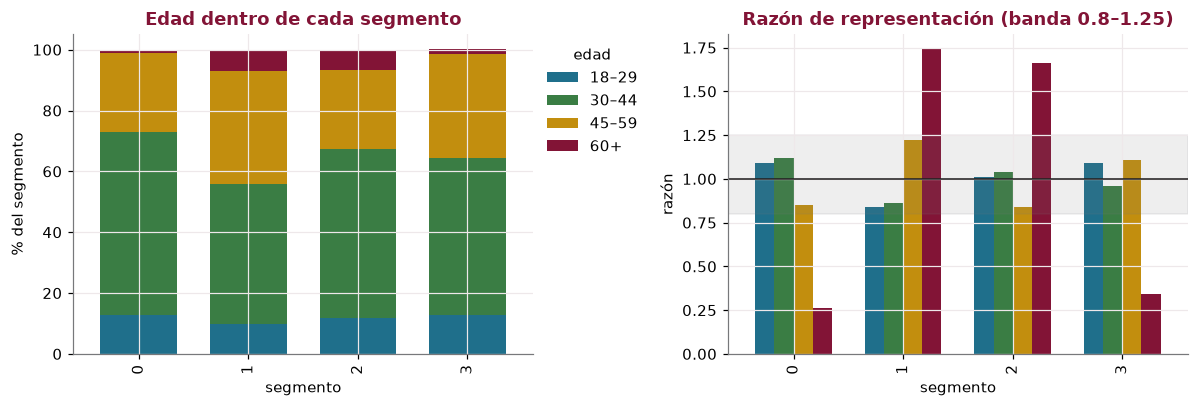

razón mínima 0.26 · razón máxima 1.74


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
comp_edad.plot.bar(stacked=True, ax=axes[0], color=[UEES["azul"], UEES["verde"], UEES["ocre"], UEES["vino"]], width=0.7)
axes[0].set(title="Edad dentro de cada segmento", ylabel="% del segmento", xlabel="segmento")
axes[0].legend(title="edad", bbox_to_anchor=(1, 1))
razon_edad.plot.bar(ax=axes[1], color=[UEES["azul"], UEES["verde"], UEES["ocre"], UEES["vino"]], width=0.7, legend=False)
axes[1].axhline(1, color="#1C1A1B", lw=1)
axes[1].axhspan(0.8, 1.25, color=UEES["gris"], alpha=0.12)
axes[1].set(title="Razón de representación (banda 0.8–1.25)", ylabel="razón", xlabel="segmento")
plt.tight_layout()
plt.show()
extremo = razon_edad.stack().agg(["min", "max"])
print(f"razón mínima {extremo['min']:.2f} · razón máxima {extremo['max']:.2f}")

**Qué observar.** Aunque la edad no entró al modelo, algunos segmentos quedan con muy pocos o con demasiados clientes de ciertos grupos de edad (razones lejos de 1). Las variables de comportamiento funcionan como **proxies**: tener hipoteca, el saldo o haber sido contactado antes se relacionan con la etapa de vida. Si el banco decide a qué segmento ofrecer mejores condiciones, puede terminar tratando distinto a un grupo de edad **sin haberlo decidido explícitamente**.

> **Respuesta de referencia**

**Reflexión · qué hacer con este hallazgo.** (1) Documentar la composición de cada segmento junto con su perfil. (2) Revisar para qué se usará: priorizar llamadas es menos riesgoso que fijar tasas o negar productos. (3) Si el uso afecta condiciones de acceso, evaluar el impacto por grupo (semana 4) y considerar restricciones. (4) Nunca ocultar el problema quitando la variable sensible del análisis: sin ella no podríamos haber detectado el desbalance.

## Autoverificación

In [12]:
assert np.isclose(km_sk.inertia_, hist_prop[-1], rtol=1e-5)
assert np.median(finales["k-means++"]) <= np.median(finales["aleatoria"]) + 1e-6, "k-means++ debería llegar a inercias iguales o menores que el inicio aleatorio."
assert tabla_k["silhouette"].idxmax() == 5 and tabla_k["Davies-Bouldin"].idxmin() == 5, "Con los blobs, k = 5 debería ganar en silhouette y Davies-Bouldin."
assert estab_blobs[5] > 0.95, "Con el k correcto la solución debería ser estable."
assert perfil["tasa_de_contratacion"].max() > 2 * perfil["tasa_de_contratacion"].min(), "Los segmentos deberían diferir en la tasa de contratación."
assert (razon_edad.to_numpy().max() > 1.25) or (razon_edad.to_numpy().min() < 0.8), "Revisa el cálculo de la razón de representación."
print("✓ E3.1 completo")

✓ E3.1 completo


## Lista de cotejo (autoevaluación del laboratorio)

- [ ] Tu Lloyd y tu k-means++ coinciden con `KMeans`.
- [ ] Elegiste k con codo, silhouette, Davies-Bouldin y estabilidad (ARI).
- [ ] Segmentaste clientes con variables de comportamiento transformadas y describiste cada segmento.
- [ ] Validaste externamente con la tasa de contratación (sin usarla para segmentar).
- [ ] Mediste la composición por edad y estado civil y discutiste los proxies.

**Reflexión:** ¿qué usos de esta segmentación serían aceptables y cuáles no, dada su composición por edad?

**Cómo te prepara para la Tarea 3:** la tarea exige segmentación validada y estable, y el análisis de composición por subgrupos (sexo, educación, edad) con tasas y razones.

## Desafío opcional con IA agéntica · Otra forma de segmentar: mezclas gaussianas

**Objetivo.** Comparar la segmentación de K-means con la de un modelo de mezclas gaussianas y validar ambas.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
En el notebook resuelto E3.1 (K-means y validación con Bank Marketing), agrega una sección que ajuste GaussianMixture con el mismo preprocesamiento y 4 grupos. Compara ambas segmentaciones con silhouette, estabilidad (ARI entre muestras bootstrap), perfiles de cada grupo y la tasa de contratación por segmento como validación externa. Explica en español cuál recomendarías y por qué.
```

**Cómo verificar el resultado**

- Las dos segmentaciones usan el mismo preprocesamiento.
- La estabilidad se mide con varias semillas o muestras.
- Cada segmento se describe con una frase, no solo con números.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.